In [1]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    EsmConfig,
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt

from jaxtyping import Bool, Float, Int

from plotly_utils import (
    imshow,
    line
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

In [2]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from interp_utils import get_hooked_state_dict, get_hooked_esm_config, get_logits_hooked_esm

In [3]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions
import tempfile

# Load ESM-coronaviridae

In [4]:
model_name = "facebook/esm2_t33_650M_UR50D"

device = "cuda"
CONTEXT_LEN = 1024
torch.autograd.grad_mode.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [5]:
model_config = ModelConfig()
model_config.da_model_name = model_name
esm_config = EsmConfig.from_pretrained(model_config.da_model_name)
esm_config.token_dropout = False
esm_config.model_name = model_name

In [6]:
REPO_ID = esm_config.model_name
special_tokens_map_file = "special_tokens_map.json"
tokenizer_config = {}
tokenizer_config["vocab_file"] = hf_hub_download(repo_id=REPO_ID, filename="vocab.txt")
tokenizer_config["model_max_length"] = CONTEXT_LEN
with open(hf_hub_download(repo_id=REPO_ID, filename=special_tokens_map_file), "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [7]:
with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

# Load model

In [8]:
# small thing to turn off annoying wand questions
os.environ["WANDB_DISABLED"] = "true"
pathogen_perplexities = dict()


# Get coronaviridae ESM
# Optionally, then switch to final LoRA finetuned fitness ESM
esm_cov_state_dict_path = "./covfit_stuff/model_ESM2_coronaviridae/pytorch_model.bin"
esm_disp = EsmForMaskedLM(esm_config).to(device)
esm_disp_state_dict = torch.load(esm_cov_state_dict_path)
del esm_disp_state_dict["esm.embeddings.position_embeddings.weight"]
del esm_disp_state_dict["esm.embeddings.position_ids"]
print(esm_disp.load_state_dict(esm_disp_state_dict))

<All keys matched successfully>


In [9]:
esm_disp.esm.embeddings.token_dropout = False

In [10]:
tokenizer = EsmTokenizer(**tokenizer_config)

hooked_esm_config = get_hooked_esm_config(esm_config, context_len=CONTEXT_LEN, use_hook_tokens=True)
hooked_esm = HookedTransformer(hooked_esm_config)
print(hooked_esm.load_state_dict(get_hooked_state_dict(esm_disp.state_dict(), hooked_esm_config)))

<All keys matched successfully>


In [11]:
apply_esm_lm_head = functools.partial(get_logits_hooked_esm, ESM2_lm_head=esm_disp.lm_head)

# Load data

In [12]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [13]:
# data loading
with open("../../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [14]:
MAX_LEN=1024
pathogen_name = "sars_cov_2_spike"
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]
D_VOCAB = hooked_esm.cfg.d_vocab

In [15]:
"""
uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]
    
    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences 

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences 
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4404
torch.Size([4404, 1024])


In [16]:
# add padding mask to model
def add_perma_hooks_to_mask_pad_tokens(
    model: HookedTransformer, pad_token: int
) -> HookedTransformer:
    # Hook which operates on the tokens, and stores a mask where tokens equal [pad]
    def cache_padding_tokens_mask(tokens: Float[Tensor, "batch seq"], hook: HookPoint) -> None:
        hook.ctx["padding_tokens_mask"] = einops.rearrange(tokens == pad_token, "b sK -> b 1 1 sK")

    # Apply masking, by referencing the mask stored in the `hook_tokens` hook context
    def apply_padding_tokens_mask(
        attn_scores: Float[Tensor, "batch head seq_Q seq_K"],
        hook: HookPoint,
    ) -> None:
        attn_scores.masked_fill_(model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"], -1e5)
        if hook.layer() == model.cfg.n_layers - 1:
            del model.hook_dict["hook_tokens"].ctx["padding_tokens_mask"]

    # Add these hooks as permanent hooks (i.e. they aren't removed after functions like run_with_hooks)
    for name, hook in model.hook_dict.items():
        if name == "hook_tokens":
            hook.add_perma_hook(cache_padding_tokens_mask)
        elif name.endswith("attn_scores"):
            hook.add_perma_hook(apply_padding_tokens_mask)

    return model


hooked_esm.reset_hooks(including_permanent=True)
hooked_esm = add_perma_hooks_to_mask_pad_tokens(hooked_esm, 1)

In [17]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

# Examining perplexities

In [25]:
for pathogen_name in ["sars_cov_2_spike", "cov_229e_s1"]:
    fasta_file = f"../../data/pathogen/{pathogen_name}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    uniq_seqs, unique_inds = np.unique(sequences, return_index=True) # For the purpose of eval, I only care about unique sequences 


    # identical code to how it's compute_node_embeddings.py
    cut_seqs = [get_protein_sequence(x, protein_coords) for x in uniq_seqs]
    cut_seqs = list(np.unique([x for x in cut_seqs if len(x) > 3])) # remove any identical sequences again in case more appear after trimming

    # create dataset
    eval_dict = {"input_ids":list(cut_seqs)}

    eval_dset = Dataset.from_dict(eval_dict)

    column_names = eval_dset.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
    eval_dataset = eval_dset.map( 
        tokenizer_for_map,
        batched=True,
        num_proc=8,
        remove_columns=column_names,
    )

    # evaluate ESM-2 model on dataset 
    evaluator = Trainer(
      model=esm_disp,
      data_collator=data_collator,
      eval_dataset=eval_dataset,
    )
    eval_results = evaluator.evaluate()
    pathogen_perplexities[pathogen_name] = math.exp(eval_results['eval_loss'])
    print(f"Pathogen: {pathogen_name}\nESM-2 Perplexity: {pathogen_perplexities[pathogen_name]:.4f}\n")

# with open("pathogen_perplexities.json", "w") as file:
#     json.dump(pathogen_perplexities, file)

Map (num_proc=8):   0%|          | 0/1699 [00:00<?, ? examples/s]

{'eval_loss': 0.943920373916626, 'eval_model_preparation_time': 0.0116, 'eval_runtime': 26.5498, 'eval_samples_per_second': 63.993, 'eval_steps_per_second': 8.023}
Pathogen: sars_cov_2_spike
ESM-2 Perplexity: 2.5700



Map (num_proc=8):   0%|          | 0/82 [00:00<?, ? examples/s]

{'eval_loss': 0.9238787293434143, 'eval_model_preparation_time': 0.0116, 'eval_runtime': 1.3146, 'eval_samples_per_second': 62.375, 'eval_steps_per_second': 8.367}
Pathogen: cov_229e_s1
ESM-2 Perplexity: 2.5190



In [26]:
uniref50_ds = load_dataset("fredzzp/Uniref50", split="test")
column_names = uniref50_ds.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
uniref_tokenizer_map = functools.partial(tokenizer_for_map, seq_key="sequence")
uniref_dataset = uniref50_ds.map( 
        uniref_tokenizer_map,
        batched=True,
        num_proc=8,
        remove_columns=column_names,
    )
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)
os.environ["WANDB_DISABLED"] = "true"

# evaluate ESM-2 model on uniref50 
evaluator = Trainer(
  model=esm_disp,
  data_collator=data_collator,
  eval_dataset=uniref_dataset[:800]["input_ids"],
)
uniref_results = evaluator.evaluate()
pathogen_perplexities["uniref50"] = math.exp(uniref_results['eval_loss'])
print(f"Uniref50 ESM-2 Perplexity: {pathogen_perplexities['uniref50']:.4f}\n")

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

{'eval_loss': 2.0747761726379395, 'eval_model_preparation_time': 0.0047, 'eval_runtime': 12.4845, 'eval_samples_per_second': 64.08, 'eval_steps_per_second': 8.01}
Uniref50 ESM-2 Perplexity: 7.9628



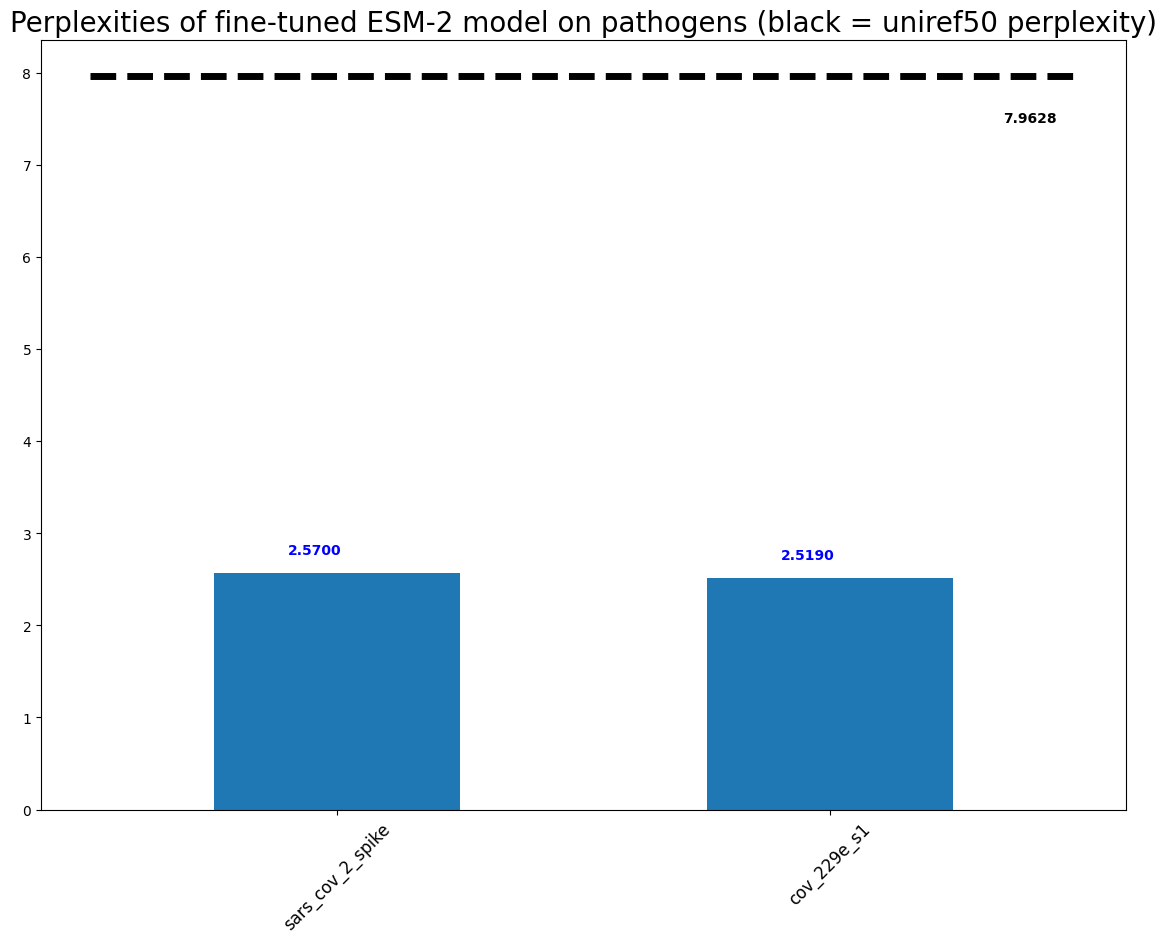

In [27]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.set_title("Perplexities of fine-tuned ESM-2 model on pathogens (black = uniref50 perplexity)",fontsize=20)
ax.bar(x=["sars_cov_2_spike", "cov_229e_s1"], height=[pathogen_perplexities[p] for p in ["sars_cov_2_spike", "cov_229e_s1"]], width=0.5)
ax.tick_params("x", rotation=45, labelsize=12)
ax.plot([-0.5,1.5], [pathogen_perplexities["uniref50"] for _ in range(2)], linestyle="dashed", color="black", linewidth=5)
for i,v in enumerate([pathogen_perplexities[p] for p in ["sars_cov_2_spike", "cov_229e_s1"]]):
    ax.text(i-0.1, v+0.2, f"{v:.4f}", color='blue', fontweight='bold')

ax.text(len(["sars_cov_2_spike", "cov_229e_s1"]) - 0.65, pathogen_perplexities["uniref50"] - .5, f"{pathogen_perplexities['uniref50']:.4f}", color="black", fontweight="bold")
fig.show()

# examining muts

In [19]:
voc_idx = [i for i,x in enumerate(seq_names) if "Wuhan" in x]
idx_idx = 0

print(seq_names[voc_idx[idx_idx]])
test_idx = seq_idxs[voc_idx[idx_idx]]
test = all_uniq_seqs[test_idx]

Wuhan-Hu-1/2019


In [29]:
print(test[441])

D


In [323]:
new_test = list(test)
new_test[484] = "<mask>"
new_test = "".join(new_test)

test_dset = tokenizer([new_test], return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)

In [325]:
output = esm_disp(test_dset).logits
torch.cuda.empty_cache()

In [341]:
i1 = aa_to_toks_map_rev["D"]
i2 = aa_to_toks_map_rev["G"]

In [350]:
print(aa_to_toks_map[16])

Q


In [351]:
print(output[0,613,16])

tensor(11.1422, device='cuda:0')


In [349]:
print(torch.max(torch.softmax(output[0,613], dim=0)))
print(torch.argmax(torch.softmax(output[0,613], dim=0)))
print(torch.softmax(output[0,613], dim=0)[[i1,i2]])

tensor(0.9998, device='cuda:0')
tensor(16, device='cuda:0')
tensor([1.0288e-05, 1.5205e-05], device='cuda:0')


In [332]:
print(output[0,613,i1], output[0,613,i2])

tensor(-0.3421, device='cuda:0') tensor(0.0485, device='cuda:0')


In [354]:
rand_sites = torch.randint(low=0,high=len(test), size=(1000,3))
print(rand_sites.shape)

torch.Size([1000, 3])


In [355]:
# co-evolving sites
coevolve_sites = [53, 213, 110, 136]


old_aa_cs = ["R", "D", "D"]
new_aa_cs = ["S", "N", "D"]


orig_test = list(test)
new_test = list(test)
null_test = []

for ncs,naa,oaa in zip(coevolve_sites[1:], new_aa_cs, old_aa_cs):
    new_test[ncs] = naa
    # orig_test[ncs] = oaa

    # new_test[ncs] = "<mask>"
    # orig_test[ncs] = "<mask>"

for i in range(rand_sites.size(0)):
    null_test_i = list(test)
    for ncs, naa in zip(rand_sites[i], new_aa_cs):
        null_test_i[ncs.item()] = naa
    null_test_i[coevolve_sites[0]] = "<mask>"
    null_test.append("".join(null_test_i))

In [356]:
orig_test[coevolve_sites[0]] = "<mask>"
new_test[coevolve_sites[0]] = "<mask>"

print("old")
for cs in coevolve_sites:
    print(orig_test[cs], end=" ")
print()

print("new")
for cs in coevolve_sites:
    print(new_test[cs], end=" ")
print()


orig_test = "".join(orig_test)
new_test = "".join(new_test)

test_dset = tokenizer([orig_test, new_test, *null_test], return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN).input_ids.to(device)

old
<mask> R D N 
new
<mask> S N D 


In [357]:
output_dset = torch.empty(rand_sites.size(0)+2, MAX_LEN, D_VOCAB)
for batch in tqdm(range(0,rand_sites.size(0)+2,100)):
    output_dset[batch:batch+100] = esm_disp(test_dset[batch:batch+100]).logits
    torch.cuda.empty_cache()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:49<00:00,  4.49s/it]


In [358]:
print(output_dset[0,coevolve_sites[0]].max())
print(output_dset[0,coevolve_sites[0]].argmax())

tensor(10.6335)
tensor(13)


In [362]:
print(aa_to_toks_map[13])

D


In [359]:
i1 = aa_to_toks_map_rev["H"]
i2 = aa_to_toks_map_rev["L"]

In [360]:
orig_diff = output_dset[0,coevolve_sites[0], i1] - output_dset[0, coevolve_sites[0], i2]
diffs_vec = output_dset[2:,coevolve_sites[0], i1] - output_dset[2:, coevolve_sites[0], i2].cpu().numpy()

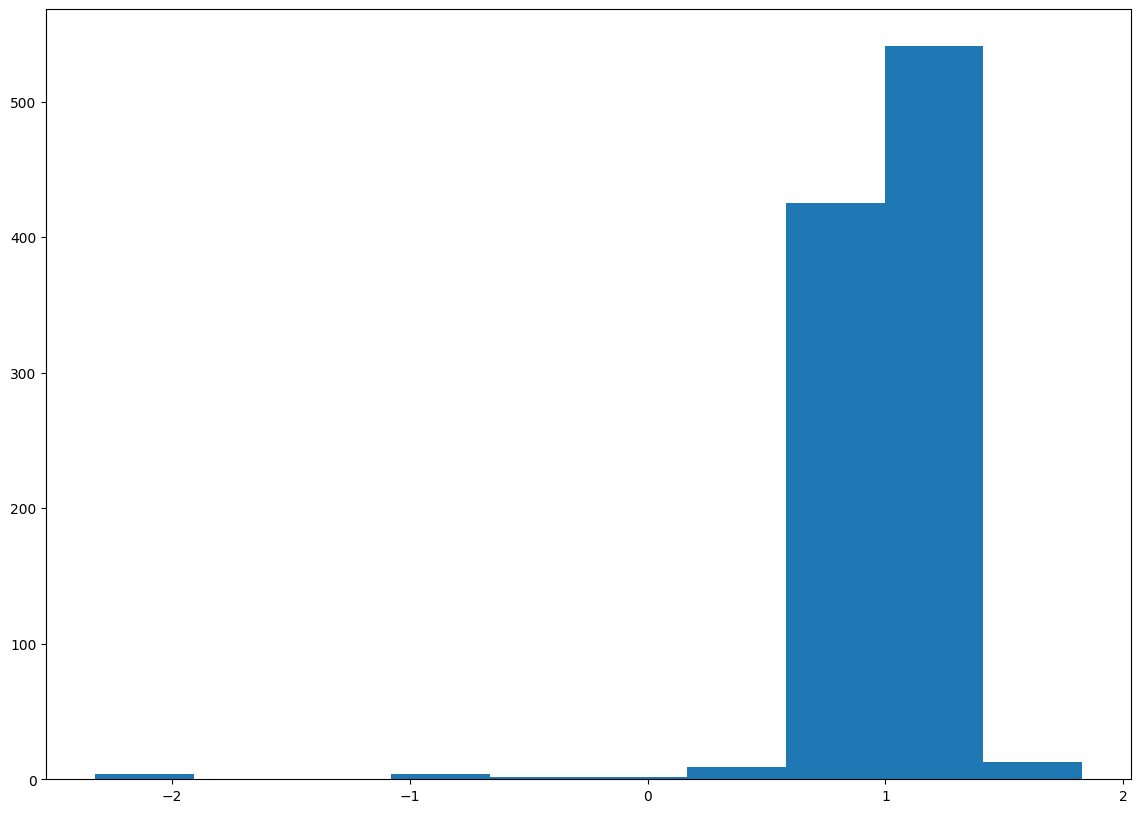

In [361]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.hist(diffs_vec)
plt.show()

In [307]:
orig_diff = output_dset[0,coevolve_sites[0], i1] - output_dset[0, coevolve_sites[0], i2]
for i in range(3):
    diff = output_dset[i,coevolve_sites[0], i1] - output_dset[i, coevolve_sites[0], i2]
    print(["orig","new","null"][i], ", ", output_dset[i,coevolve_sites[0], [i1,i2]], ",", (diff - orig_diff).item())

orig ,  tensor([-1.0125, -1.9572]) , 0.0
new ,  tensor([-0.8377, -2.1499]) , 0.3673897981643677
null ,  tensor([-1.0109, -1.9959]) , 0.04027831554412842


# Finding copy heads

In [34]:
torch.manual_seed(0)
rand_idx = torch.randperm(200)
test_dset = tok_seqs[rand_idx, :]

In [35]:
# resid_component_names = ["blocks.0.hook_resid_pre"]
# for layer in range(hooked_esm.cfg.n_layers):
#     resid_mid_name = f"blocks.{layer}.hook_resid_mid"
#     resid_post_name = f"blocks.{layer}.hook_resid_post"
#     resid_component_names.append(resid_mid_name)
#     resid_component_names.append(resid_post_name)
    
# def patch_resid_direct_to_regressor(toks: Float[Tensor, "n_data d_vocab"], model, logit_id=logit_id, resid_component_names=resid_component_names):
#     n_data = toks.size(0)
#     _, resid_cache = model.run_with_cache(toks, names_filter=resid_component_names)
#     torch.cuda.empty_cache()

#     logit_results = torch.zeros(n_data, len(resid_component_names)).to(device) #[n_data n_components]
#     final_ln = model.ln_final

#     # run regressor model on residual stream at each layer (including before attn0 and after final layer norm)
#     for i, component in enumerate(resid_component_names):
#         resid_component = final_ln(resid_cache[component])
#         logit_results[:, i] = get_logit_hooked(resid_component, tok_id=logit_id)

#     return logit_results

torch.Size([200, 1024])


# Interp seeing which attention heads impact fitness estimate the most